In [17]:
#Celda 1 -Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
# Celda 2 - Cargar datos
df_siniestros = pd.read_excel(r"C:\Users\jason\OneDrive\Documentos\GitHub\Portafolio-data-science\proyecto-1-infraestructura-bogota\01_Datos\siniestros_viales_consolidados_bogota_dc.xlsx")

df_pavimento = pd.read_csv(r"C:\Users\jason\OneDrive\Documentos\GitHub\Portafolio-data-science\proyecto-1-infraestructura-bogota\01_Datos\estado_122024.csv", sep=';')

print(f"Siniestros: {df_siniestros.shape[0]:,} filas, {df_siniestros.shape[1]} columnas")
print(f"Pavimento:  {df_pavimento.shape[0]:,} filas, {df_pavimento.shape[1]} columnas")



Siniestros: 196,152 filas, 10 columnas
Pavimento:  103,300 filas, 4 columnas


In [18]:
# Celda 3 - Explorar estructura
print("=== SINIESTROS VIALES ===")
print(df_siniestros.columns.tolist())
print(f"\nPrimeras filas:")
df_siniestros.head(3)


=== SINIESTROS VIALES ===
['CODIGO_ACCIDENTE', 'FECHA', 'HORA', 'GRAVEDAD', 'CLASE', 'CHOQUE', 'OBJETO_FIJO', 'DIRECCION', 'CODIGO_LOCALIDAD', 'DISENO_LUGAR']

Primeras filas:


,CODIGO_ACCIDENTE,FECHA,HORA,GRAVEDAD,CLASE,CHOQUE,OBJETO_FIJO,DIRECCION,CODIGO_LOCALIDAD,DISENO_LUGAR
0,4401438,01/01/2015,01:05:00,2,2,NaN,NaN,KR 64A-CL 2C 02,16,2
1,4401449,01/01/2015,05:50:00,2,3,NaN,NaN,AV AVENIDA DEL SUR-KR 65A 41,7,1
2,4401430,01/01/2015,07:15:00,2,3,NaN,NaN,KR 19D-CL 62 S 02,19,1


In [20]:
#Celda 4 - Esxplorar pavimento
print("=== ESTADO PAVIMENTO===")
print(df_pavimento.columns.tolist())
print(f"\nValores únicos en ESTADO_SUPERFICIAL:")
print(df_pavimento['ESTADO_SUPERFICIAL'].value_counts())

=== ESTADO PAVIMENTO===
['OBJECTID *', 'ESTADO_SUPERFICIAL', 'FECHA_ESTADO', 'CalCodigo *']

Valores únicos en ESTADO_SUPERFICIAL:
ESTADO_SUPERFICIAL
SATISFACTORIO    59850
BUENO            28805
GRAVE             8278
JUSTO             2913
MUY POBRE         1340
POBRE             1196
8                  850
9                   27
12                  23
13                  18
Name: count, dtype: int64


In [24]:
#Celda 5 - Limpieza de datos:
#Limpiarw pavimento: quedarse solo con categorías válidas
estados_validos = ['SATISFACTORIO','BUENO', 'JUSTO', 'GRAVE', 'POBRE', 'MUY POBRE']
df_pavimento_limpio = df_pavimento[df_pavimento['ESTADO_SUPERFICIAL'].isin(estados_validos)].copy()

#Limpiar siniestros: eliminar filas sin localidad
df_siniestros_limpio = df_siniestros.dropna(subset=['CODIGO_LOCALIDAD']).copy()

print(f"Pavimento limpio : {df_pavimento_limpio.shape[0]:,} filas")
print(f"Siniestros limpio: {df_siniestros_limpio.shape[0]:,} filas")
print(f"\nDatos eliminados pavimento: {df_pavimento.shape[0] - df_pavimento_limpio.shape[0]} filas" )
print(f"Datos eliminados siniestros: {df_siniestros.shape[0] - df_siniestros_limpio.shape[0]} filas")



Pavimento limpio : 102,382 filas
Siniestros limpio: 196,152 filas

Datos eliminados pavimento: 918 filas
Datos eliminados siniestros: 0 filas


In [27]:
#Celda 6 - Accidentes por localidad
accidentes_localidad = df_siniestros_limpio.groupby('CODIGO_LOCALIDAD').size().reset_index()
accidentes_localidad.columns = ['CODIGO_LOCALIDAD', 'TOTAL_ACCIDENTES']
accidentes_localidad = accidentes_localidad.sort_values('TOTAL_ACCIDENTES', ascending=False)

print(accidentes_localidad.head(10))





    CODIGO_LOCALIDAD  TOTAL_ACCIDENTES
7                  8             22282
9                 10             19777
0                  1             19621
10                11             17759
8                  9             15598
15                16             13876
1                  2             11502
11                12             10467
12                13             10317
6                  7              9684


In [28]:
#Celda 7 - Agregar nombres ded localidades
nombres_localidades = {
1: 'Usaquén', 2: 'Chapinero', 3: 'Santa Fe', 4: 'San Cristóbal',
    5: 'Usme', 6: 'Tunjuelito', 7: 'Bosa', 8: 'Kennedy',
    9: 'Fontibón', 10: 'Engativá', 11: 'Suba', 12: 'Barrios Unidos',
    13: 'Teusaquillo', 14: 'Mártires', 15: 'Antonio Nariño', 16: 'Puente Aranda',
    17: 'Candelaria', 18: 'Rafael Uribe', 19: 'Ciudad Bolívar', 20: 'Sumapaz'
} 

accidentes_localidad['NOMBRE_LOCALIDAD'] = accidentes_localidad['CODIGO_LOCALIDAD'].map(nombres_localidades)
print(accidentes_localidad.head(10))

    CODIGO_LOCALIDAD  TOTAL_ACCIDENTES NOMBRE_LOCALIDAD
7                  8             22282          Kennedy
9                 10             19777         Engativá
0                  1             19621          Usaquén
10                11             17759             Suba
8                  9             15598         Fontibón
15                16             13876    Puente Aranda
1                  2             11502        Chapinero
11                12             10467   Barrios Unidos
12                13             10317      Teusaquillo
6                  7              9684             Bosa


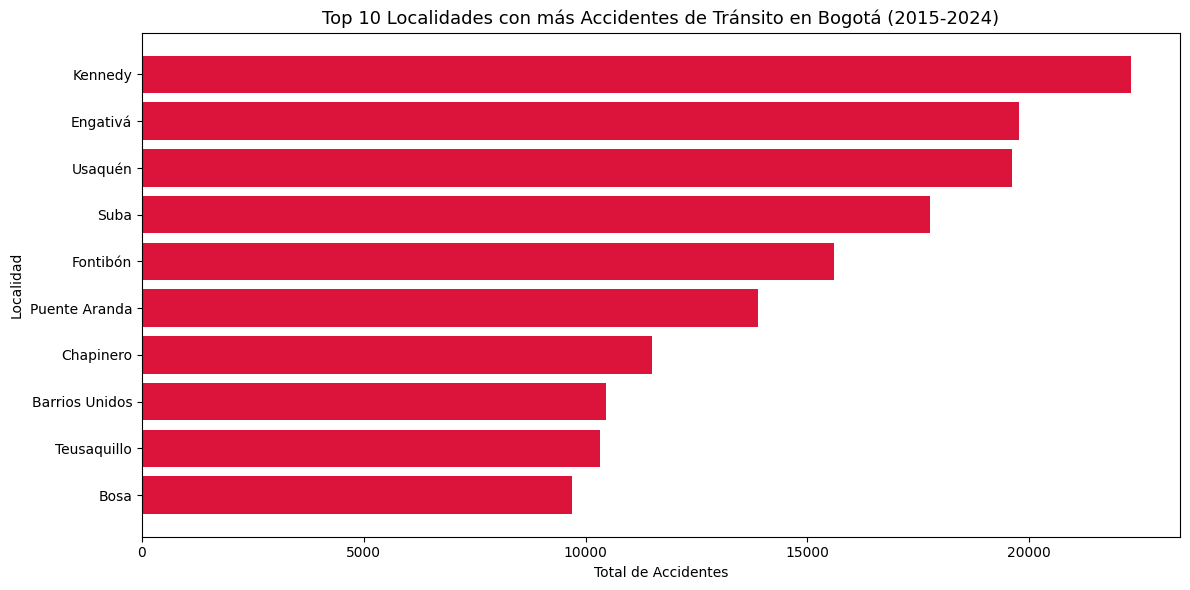

✅ Gráfica guardada


In [ ]:
#Celda 8 - Gráfica de accidentes por localidad
plt.figure(figsize=(12, 6))
datos_grafica = accidentes_localidad.head(10).sort_values('TOTAL_ACCIDENTES')
plt.barh(datos_grafica['NOMBRE_LOCALIDAD'], datos_grafica['TOTAL_ACCIDENTES'], color='crimson')
plt.title('Top 10 Localidades con más Accidentes de Tránsito en Bogotá (2015-2024)', fontsize=13)
plt.xlabel('Total de Accidentes')
plt.ylabel('Localidad')
plt.tight_layout()
plt.savefig(r'C:\Users\jason\OneDrive\Documentos\GitHub\Portafolio-data-science\proyecto-1-infraestructura-bogota\grafica_accidentes_localidad.png', dpi=150)
plt.show()
print("✅ Gráfica guardada")